# Класифікація ландшафтів за допомогою моделі HAND (Height Above Nearest Drainage)

## Що таке HAND і як він обчислюється

**Height Above Nearest Drainage (HAND)** – це топографічна модель, що відображає висоту кожної точки місцевості відносно найближчого русла (водотоку). По суті, HAND для даної точки – це вертикальна різниця висот між цією точкою та найближчою точкою струмка, визначеною вздовж напрямку поверхневого стоку. HAND розраховується на основі цифрової моделі рельєфу (ЦМР): спочатку виділяється мережа водостоків (русел) за допомогою алгоритмів розрахунку стоку, потім для кожної комірки растру визначається найнижча точка на найближчому руслі (як правило, вниз за потоком) і обчислюється різниця висот. Ця модель була вперше запропонована Nobre та ін. (2011) як «гідрологічно значуща» метрика рельєфу.

HAND має важливу властивість: він безпосередньо пов’язує топографію з гідрологією. Низькі значення HAND відповідають місцевостям, близьким до рівня водотоку (наприклад, заплавам, днищам долин), а високі значення – підвищеним ділянкам (вододілам, схилам, плато). Завдяки цьому HAND отримав широке застосування в аналізі ландшафтів і паводковому моделюванні. Наприклад, його широко застосовують для оцінки вологості ґрунтів, глибини залягання ґрунтових вод та моделювання затоплень.

*Як обчислити HAND:* Практично алгоритм розрахунку полягає в наступному: (1) з ЦМР визначаються потоки та формується растр русел (наприклад, методом порогу площі водозбору або мінімального струмка); (2) для кожної клітини ЦМР (не належної до русла) простежується шлях стоку вниз до найближчої клітини-руслового пікселя; (3) HAND дорівнює різниці висоти цієї клітини над висотою відповідного руслового пікселя. Важливо правильно задати поріг формування русел, адже від нього залежить, які точки вважатимуться "руслом". Наприклад, в одному з досліджень поріг площі водозбору для ініціації струмків було обрано 10 га, щоб сітка русел ЦМР відповідала карті річкової мережі. Багато ГІС-інструментів вже мають реалізацію такого розрахунку: у GRASS GIS модуль `r.watershed` та аддон `r.hand` виконують ці кроки автоматично, у SAGA GIS аналогічний результат дає функція **“Overland Flow Distance to Channel (Vertical)”**, яка фактично обчислює HAND і може використовувати різні методи розрахунку напрямків стоку.

## Картування заплав за допомогою HAND

Одне з перших і найочевидніших застосувань HAND – **виділення потенційних заплав**. Логіка полягає в тому, що ділянки з малими значеннями HAND розташовані близько до рівня русла і, ймовірно, затоплюються під час паводків. Простий підхід – задати граничне значення HAND для класифікації заплав. Наприклад, можна припустити, що всі території, чия висота менше ніж на 2 м перевищує рівень найближчого русла, належать до сучасної заплави (це умовний поріг, який може варіюватися залежно від масштабу річки і місцевого рельєфу). В літературі зустрічаються подібні емпіричні пороги: так, Nobre та ін. запропонували класифікувати ландшафт Амазонії за HAND на три зони – **«поверхневий рівень ґрунтових вод»** при HAND 0–5 м, **«мілкий водоносний горизонт»** при 5–15 м та **«глибокий водоносний горизонт»** при HAND >15 м. Першій категорії (0–5 м) відповідають якраз заплави та дуже низькі рівні над руслом, де ґрунтові води близько до поверхні і можливе часте перезволоження.

Інші дослідники калібрували пороги на основі польових даних. Наприклад, для мезомасштабного басейну в Центральній Європі Гхарарі та ін. (2011) знайшли, що поріг HAND \~6 м оптимально відділяє низинні **вологі ділянки** (заплави, болота) від підвищених частин ландшафту. При цьому використовувався ще й поріг ухилу (близько 12–13% нахилу): рівнинні місця з HAND <6 м класифікувалися як заплавні **«болотисті» ділянки**, тоді як більш круті схили навіть при невеликому HAND не відносилися до заплав, а інтерпретувалися як круті укоси русла. Це підкреслює, що просте порогове правило можна покращити, додаючи інші критерії (напр. похил), аби відрізнити плоску заплаву від вузького крутого каньйону.

&#x20;*Приклад карти заплав, визначених за допомогою HAND та порогів ухилу: синім кольором показано ділянки, що мають низький HAND і пологий рельєф, виділені як потенційні заплави (басейн Mid Bailey Run, Огайо, США).*

Більш просунуті методи уникають жорсткого ручного вибору порогу, натомість обчислюють його статистично з даних рельєфу. Так, Clubb та ін. (2017) запропонували автоматичне вилучення заплав на основі **подвійного критерію** – локального ухилу і висоти над руслом. В їх методі спочатку згладжують ЦМР, потім для кожної точки обчислюють HAND (відносну висоту над каналом) та ухил, після чого аналізують розподіл цих показників по всій території за допомогою квантиль-квантильного графіку. На основі відхилення емпіричного розподілу від теоретичного визначають порогові значення ухилу і HAND, нижче яких точки статистично належать до аномально плоских і низьких – тобто до заплав. Усі пікселі, що мають **одночасно менший за пороговий ухил і менший за пороговий HAND**, позначаються як заплави (бінарна маска). Таким чином пороги «підлаштовуються» під характер рельєфу конкретного регіону без суб’єктивного вручну заданого значення. Цей метод було успішно апробовано на реальних даних (напр. для долин річок в Огайо) – отримані карти заплав узгоджувалися з візуально розпізнаними терасами і заплавами на цифровій моделі.

Важливо відзначити, що при виділенні заплав за HAND слід ураховувати **гідрологічну зв’язаність** територій. Просте порівняння висоти може включити ділянки, відрізані від річки природними валами чи дамбами. Тому бажано перевіряти, чи область з низьким HAND має безперервний шлях потоку до русла. В алгоритмі Clubb та ін. це робиться через аналіз зв’язних компонент: всі пікселі, що відповідають критеріям заплави і **зв’язані з основним руслом**, маркуються як власне заплава, а ізольовані «плями» низького HAND розглядаються як відокремлені тераси.

## Автоматична класифікація русел, заплав, терас і схилів

Методологія HAND дозволяє **автоматично розподілити територію на гідроморфологічні класи** – русла, заплави, тераси, схили, вододіли тощо – на основі топографічних критеріїв. Основні підходи тут такі:

* **Порогове деревце рішень (thresholding)**: визначаються одне чи кілька граничних значень показників (HAND, ухил, відстань до русла тощо), за якими відбувається розбиття на класи. Це фактично просте дерево рішень. Приклад – вже згадана схема Гхарарі та ін. (2011) із трьома класами: якщо ухил пологий і HAND низький – класифікується як *заплавна низина* (еквівалент сучасної заплави або болота); якщо ухил пологий, але HAND високий – це *підвищена рівнина* або плато; якщо ухил значний – це *схилова зона*, незалежно від абсолютної висоти над руслом (бо круті ділянки рельєфу з малою HAND типово є стінками ярів чи каньйонів, а не заплавою). У цій моделі пороги (\~0.13 для схилу та \~6 м для HAND) було підібрано так, щоб модельовані класи найкраще відповідали спостереженим у полі гідрологічним режимам (вологі низини, схили з боковим стоком, плато з глибоким інфільтраційним стоком). Важливо, що перехід між класами в реальності поступовий, тому автори вводили *«нечіткі» пороги* – поступову зміну ймовірності приналежності до того чи іншого класу замість різкого розділення. Але сама ідея залишається зрозумілою: HAND виступає ключовим параметром, що разом з ухилом “читає” ландшафт і ділить його на елементи річкової долини.

* **Класифікація на основі алгоритмів машинного навчання**: замість ручного вибору порогів можна навчити модель (рішення приймає алгоритм на основі навчальних даних). Наприклад, якщо є набір точок, позначених експертом як «заплава», «тераса», «схил» тощо, можна побудувати класифікатор (як-от рішення деревом або випадковим лісом), який вивчить закономірності HAND, ухилів, геоморфометричних індексів для кожного класу. HAND часто використовується як важлива ознака у таких моделях. Зокрема, згадується, що в алгоритмах автоматичного **Floodplain Mapping** (виділення зон затоплення) HAND залучають як один з ключових індикаторів рельєфу. Машинне навчання може поєднувати HAND з іншими шарами (напр. відстань до річки, кривизна рельєфу, індекс вологість TWI) і будувати більш комплексні розділові правила, ніж просте порогове. Наприклад, у роботі Marchesini et al. (2021) застосовано логістичну регресію для прогнозу ймовірності затоплення, де HAND входить як один із предикторів, а в інших дослідженнях – випадкові ліси для картування схильності території до паводків, де HAND показав високий внесок у моделі. Подібні підходи дозволяють врахувати *нелінійні комбінації* факторів і отримати ймовірнісну оцінку приналежності до класу (наприклад, ймовірність, що точка – заплава, на основі її HAND та інших параметрів) замість жорсткого поділу.

* **Виділення терас і стародавніх заплав**: HAND допомагає ідентифікувати не лише активну (сучасну) заплаву, але й рівні старих терас. Підхід, запропонований Hergarten et al. (2014) і реалізований в LSDTopoTools, передбачає аналіз поздовжнього профілю долини. Для заданого відрізку річки будується так званий *swath profile* – поперечний профіль рельєфу вздовж траси річки – і визначаються горизонтальні плато (ділянки зі схожою висотою над руслом) по обидва боки долини. Використовуючи статистично обґрунтовані пороги ухилу і висоти, алгоритм виокремлює такі ділянки як **тераси** та присвоює їм висотні рівні відносно сучасного русла. Результат – карта терасових рівнів уздовж долини, де кожна тераса отримує унікальний ID та значення висоти над річкою. На практиці користувач може задати мінімальну висоту тераси (щоб відсіяти заплаву, напр. >5 м над руслом) та мінімальний розмір площі тераси для врахування.

&#x20;*Виділення терас за допомогою HAND у гірському рельєфі: червоним показані рівні терас вздовж долини (чим темніший відтінок, тим вище тераса над сучасним руслом). Приклад з басейну South Fork Eel River, Каліфорнія.*

**Застосування для гірських регіонів:** У горах (таких як Українські Карпати) метод HAND теж може бути ефективно застосований, але слід врахувати деякі особливості. По-перше, гірські річки мають стрімкі схили і вузькі заплави, тож абсолютні пороги HAND для заплав можуть бути меншими (скажімо, <2–3 м для малих потічків) або потребують калібрування за спостереженими паводками. По-друге, високе розчленування рельєфу означає, що багато ділянок з невеликим HAND можуть бути крутими схилами каньйону, які не є заплавою – тому комбінування критерію HAND з ухилом особливо важливе в горах. По-третє, в гірських долинах часто присутні *тераси* – залишки старих заплав на певній висоті над річкою. Вищезгаданий інструмент LSDTopoTools показав здатність виявляти тераси навіть у складному рельєфі (див. рис. вище). Для Карпат чи інших подібних ландшафтів світу можна застосувати ці підходи, за необхідності адаптувавши пороги: наприклад, виділяти заплави першого рівня при HAND до кількох метрів, тераси – вищі рівні (десятки метрів над рікою), а схили – ділянки з великим ухилом незалежно від висоти.

## Моделювання паводкового затоплення з використанням HAND

Однією з найбільш розвинених областей застосування HAND є **швидке моделювання зон затоплення під час паводків**. Методика іноді називається *HAND flood inundation mapping*. Її суть: якщо відомо, до якого рівня підніметься вода в річці (наприклад, для заданої витрати або сценарію паводку), то всі території, чиї значення HAND нижчі за цей підйом води, потенційно будуть затоплені. Інакше кажучи, маючи карту HAND, можна просто порівнювати її з прогнозованою висотою підйому води над руслом: де HAND < H (H – висота води над дном русла), там малюється затоплення.

На практиці це вимагає встановлення зв’язку між гідрологічними величинами (витратою води, рівнем води) та висотою затоплення. Найчастіше використовують підхід через **калібрування розрахункових кривих витрата-рівень** (rating curves) для кожної ділянки річки. В рамках проєкту HAND в США (GeoFlood, Університет штату Техас) було попередньо обчислено для багатьох річкових сегментів значення HAND, при яких починається вихід води з русла, і побудовано синтетичні криві “витрата–рівень”. Поєднання цих кривих з прогнозами витрати від гідрологічних моделей (наприклад, National Water Model) дає можливість дуже швидко отримувати карти затоплення для великих територій. Такий підхід називають низько-складним (low-complexity) на відміну від детальних гідродинамічних моделей: він не враховує складної фізики потоків, а базується лише на геометрії рельєфу, але зате **значно швидший** і менш вимогливий до даних.

Наприклад, Johnson та ін. (2019) оцінили метод NWM-HAND для 11 штатів США і показали, що він правильно відображає \~76–80% зон затоплення порівняно з офіційними FEMA Flood Maps. Метод дещо схильний **перевищувати** площу затоплення (тобто показувати трохи більші зони, ніж реально спостерігалися), але це навіть бажано з точки зору перестрахування. Інші дослідження підтвердили придатність HAND-моделі для регіонів зі складною гідрографією, демонструючи відповідність гідродинамічним моделям у прогнозі глибини води при паводках. У більшості випадків розбіжності пояснюються тим, що HAND не враховує локальних гідравлічних особливостей – наприклад, штучних дамб, мостів, заплавних озер або розливу на сусідні водозбори, – адже алгоритм просто затоплює все, що нижче певної висоти над руслом і гідрологічно зв’язане з ним. Тому для критичних об’єктів застосування HAND-карт потребує експертної перевірки або комбінування з іншими даними (напр. супутниковими знімками затоплення). Втім, як основа системи оперативного прогнозування паводків, HAND зарекомендував себе дуже добре.

*Формально*, процедура моделювання затоплення така: для кожного сегмента річки визначається, на яку висоту підніметься рівень води (наприклад, зі спостережень або моделі витрат). Потім всі пікселі з HAND меншим або рівним цій висоті позначаються як затоплені. Глибину води на даному пікселі можна оцінити як H – HAND (де H – висота підйому води над руслом для відповідного річкового сегмента). Так отримують як площу затоплення, так і грубий розподіл глибин. Цей підхід часто реалізований у ГІС-інструментах. Наприклад, модуль GRASS `r.hand` дозволяє задати *depth* (глибину води) і генерує растр затоплення для всіх комірок з HAND нижче цієї глибини. Можна також задати серію рівнів води і отримати декілька карт затоплення (для різних сценаріїв) одним запуском.

Щоб пов’язати це з реальними гідрологічними величинами, використовують так звані **синтетичні криві витрата-висота** (Synthetic Rating Curves). Вони будуються, виходячи з геометрії поперечного профілю долини, яку «бачить» HAND. Простими словами, якщо багато пікселів навколо русла мають HAND, скажімо, 3 м, то при підйомі води на 3 м затопиться значна територія – тобто цій висоті відповідає певна характерна площа затоплення і, з врахуванням ширини долини, певна витрата. Є різні моделі для отримання таких залежностей. У згаданій роботі Afshari et al. (2018) порівнювали два інструменти – HAND та AutoRoute – і підтвердили, що HAND на основі DEM може досить точно оцінити криві "витрата-площа затоплення" у порівнянні з 2D HEC-RAS. Сьогодні існують цілі фреймворки, що будують **імовірнісні карти паводків** на основі HAND. Jafarzadegan & Merwade (2019) запропонували підхід, де замість одного порогу HAND використовується *імовірнісна функція*: ймовірність затоплення плавно зменшується із зростанням HAND за експоненційним або лог-нормальним законом, параметри якого підбираються за даними 100-річних паводків. Такий метод дає не бінарну карту, а карту ймовірностей затоплення, що може бути корисно для оцінки ризиків.

## Реалізація в ГІС (QGIS, ArcGIS, Python)

**QGIS / SAGA / GRASS:** Завдяки інтеграції ГІС-модулів, розрахувати HAND та використовувати його для класифікації можна безпосередньо в QGIS. Як зазначалося, у SAGA GIS є модуль **“Overland Flow Distance to Channel (Vertical)”**, який по суті рахує HAND – достатньо подати йому ЦМР і карту русел (або автоматично згенерувати їх на основі порогу накопичення стоку). У GRASS GIS існує аддон **`r.hand`**, що може одночасно обчислити растр HAND і побудувати карти затоплення для заданих рівнів води. В ArcGIS аналогічного інструменту «з коробки» може не бути, але можна використати ArcPy: наприклад, інструмент **Flow Distance** (Spatial Analyst) дозволяє обчислити відстань вздовж потоку – за допомогою нього та різниці висот можна алгоритмічно отримати HAND. Також спільнотою розроблені скрипти моделі для ArcGIS (деякі доступні на GeoNet), які автоматизують цей процес: як правило, вони виконують заповнення депресій, визначення русел (наприклад, методом D8 з порогом), а далі для кожної комірки здійснюють пошук вниз по потоку і віднімання висот.

**Python:** Існують незалежні реалізації алгоритму HAND на Python. Наприклад, можна використати бібліотеки для рельєфного аналізу (RichDEM, WhiteboxTools) чи навіть NetworkX для обходу графа стоків. Принцип такий самий: знайти для кожної вершини (пікселя) найближчу «стічну» вершину і порахувати дельту висот. Задача добре паралелізується, тож для високороздільних DEM є реалізації на C++/OpenMP (той же LSDTopoTools). До речі, для глобальних оцінок були створені готові набори даних: наприклад, у відкритому доступі є глобальна карта HAND з роздільною здатністю 3 arc-second (\~90 м) і 1 arc-second (\~30 м) на основі SRTM – її застосовували для оцінки затоплень у країнах, де детальних даних мало. В Україні можна самостійно побудувати HAND з використанням доступних DEM (наприклад, LIDAR-даних або SRTM). За наявності детальної ЦМР це дасть змогу дешево отримати картину заплав і потенційних зон затоплення, а також використати HAND як додатковий шар при моделюванні паводків чи ландшафтному районуванні.

**Посилання на ресурси:** Для глибшого ознайомлення рекомендуємо оригінальну роботу Nobre et al. (2011) – вона закладає основу методології HAND і наводить приклади класифікації земель за ґрунтово-гідрологічними умовами. Стаття Gharari et al. (2011) демонструє використання HAND у поєднанні з ухилом для виділення гідрологічно однорідних ландшафтних класів. Керівництво **LSDTopoTools** від Fiona Clubb (2017) детально описує алгоритми вилучення заплав і терас зі статистичними порогами, що буде корисно для роботи в гірських районах. Для паводкового моделювання варто звернути увагу на роботи Afshari et al. (2018) і Johnson et al. (2019), де оцінено точність і переваги HAND-методу в порівнянні зі складнішими моделями. Також, **GRASS GIS manual** для `r.hand` містить практичні приклади команд та посилання на першоджерела. Всю цю літературу можна використовувати як наукове підґрунтя та методичні вказівки для реалізації класифікації ландшафтів за допомогою HAND.

**Висновок:** HAND – потужний інструмент, що дозволяє на основі даних рельєфу виконувати **картування заплав**, **класифікацію ландшафтних форм** (русла, заплави, тераси, схили) та **швидке моделювання паводків**. Методики можуть бути простими (пороговими) або вдосконаленими (нечіткі критерії, машинне навчання), але всі вони спираються на одну ідею – висота над руслом є ключовим фактором, який визначає гідрологічний режим місцевості. В гірських умовах потрібна додаткова увага до ухилів і локальних особливостей, проте існуючі дослідження показують, що правильне застосування HAND (у поєднанні з іншими топографічними індексами) успішно працює і в складному рельєфі. Наведені наукові публікації і інструменти ГІС надають повне методологічне обґрунтування та приклади реалізації цих підходів на практиці.

**Джерела та література:**

1. Nobre, A.D. et al. (2011). *Height Above the Nearest Drainage – a hydrologically relevant new terrain model.* Journal of Hydrology, 404(1–2), 13–29.

2. Gharari, S. et al. (2011). *Hydrological landscape classification: investigating the performance of HAND based landscape classifications.* Hydrol. Earth Syst. Sci., 15, 3275–3291.

3. Clubb, F.J. et al. (2017). *Geomorphometric delineation of floodplains and terraces using local slope and height above channel.* Earth Surf. Dynam., 6, 551–575 (and LSDTopoTools documentation).

4. Johnson, J.M. et al. (2019). *An integrated evaluation of the NWM–HAND flood mapping methodology.* Nat. Hazards Earth Syst. Sci., 19(11), 2405–2420.

5. Jafarzadegan, K.J., & Merwade, V. (2019). *Probabilistic floodplain mapping using HAND-based statistical approach.* Geomorphology, 324, 48–61.

6. GRASS GIS Manual – **r.hand**: Height Above Nearest Drainage (2025).

7. LSDTopoTools User Guide – *Floodplain and Terrace Extraction* (2018).

8. SAGA GIS Manual – Overland Flow Distance to Channel (Vertical) (2020).


# Класифікація рельєфу долин у гірських районах: огляд даних та методів

## Джерела ЦМР та оцінка точності DEM

Для дослідження рельєфу в Українських Карпатах (басейн Білого Черемоша) доцільно використовувати кілька цифрових моделей рельєфу (ЦМР) різного походження – щонайменше 7 DEM для порівняння. Нижче наведено основні глобальні DEM (\~30 м), які варто проаналізувати, та їх характеристики:

* **SRTM (Shuttle Radar Topography Mission):** Радарна ЦМР (\~30 м) 2000 р., охоплює весь світ. Має похибки, особливо в горах і під лісом (\~5–15 м RMSE залежно від рельєфу). NASADEM – оновлена версія SRTM.
* **ASTER GDEM:** Оптична стерео-ЦМР (\~30 м) від датчика ASTER. Як правило, найменш точна: RMSE часто >10 м, з великими похибками на схилах і у рівнинних районах.
* **ALOS AW3D30:** Радарна ЦМР (\~30 м) JAXA. Дослідження показують, що AW3D30 – одна з найбільш стабільних і точних моделей, з найменшою варіабельністю похибок серед глобальних DEM.
* **TanDEM-X DEM:** Радарна інтерферометрична ЦМР (\~12 м, агрегована до 30 м) 2010–2015 рр. Містить систематичну похибку через ліс і рельєф (очікувана RMSE \~10–12 м).
* **Copernicus DEM:** Покращена версія TanDEM-X (редагована, без артефактів). Значно вища точність у горах: у Карпатах RMSE (90 м версії) зменшено з \~24 м (TanDEM-X) до \~9 м. 30-метрова Copernicus DEM має подібну точність \~6–9 м. Важливо врахувати, що \~26% пікселів Copernicus DEM заповнено даними інших моделей (SRTM, ASTER тощо), тому для багаточасових аналізів слід перевіряти «mask» заповнення.
* **MERIT DEM:** Об’єднана ЦМР (\~90 м) з очищенням SRTM/ASTER (усунення лісу та помилок). Має високу точність на рівнинах (RMSE \~3–6 м), але в горах похибка зростає (\~12–14 м). MERIT більш чутливий до крутого схилу – на схилах >35° RMSE може сягати \~20–27 м.
* **FABDEM (Forest And Buildings Removed DEM):** Новітня ЦМР (\~30 м), отримана машинним навчанням шляхом корекції SRTM для видалення лісу й забудови. Валідація за даними ICESat-2 показала, що FABDEM значно знижує зміщення (bias) від лісу й міст, однак не повністю: середній позитивний зсув \~3 м у містах (недостатнє «зрізання» будівель). Під лісом FABDEM зменшує висоти крон \~на 50%, але все ще має значні похибки – середня абсолютна помилка \~14 м у горах проти \~3 м на рівнинах.

Для оцінки точності DEM необхідно використати **контрольні висоти**: це або наземні дані високої точності (GPS-точки, рівні), або сторонні моделі рельєфу (напр. локальні LiDAR-DTM), або *альтиметричні виміри супутників* (ICESat-2, GEDI). Виробники Copernicus DEM, напр., використовували дані лазерної альтиметрії ICESat для перевірки точності під час створення моделі. Рекомендується обчислити метрики **RMSE**, **систематичну похибку (ME, bias)**, **MAE** та ін. між DEM і опорними точками. У випадку ненормального розподілу похибок варто використовувати робастні метрики, зокрема **NMAD** (нормалізоване медіанне абсолютне відхилення). Необхідно врахувати залежність помилок від умов місцевості: похибка DEM зростає на крутих схилах і в лісах. Для контролю можна залучити дані **ICESat-2** (ATL08 або ATL03) – існують інструменти для вибірки точок ICESat-2 на дану територію (напр. бібліотека `icepyx` або API NASA OpenAltimetry). Дослідження підтверджують ефективність використання ICESat-2: зокрема, порівняння \~ 30 м FABDEM з висотами ICESat-2 дозволило кількісно оцінити усунення похибок від покриву.

## Геоморфометричні індекси для річкових долин

**Аналіз похідних DEM** (derivatives) є ключем до класифікації форм рельєфу долин. Найінформативніші показники: **нахил поверхні (slope)**, **кривизна** (поздовжня та поперечна), **показники вологозабезпечення** та акумуляції (наприклад, *Topographic Wetness Index*, **TWI**), **відносна висота над руслом** (*Height Above Nearest Drainage*, **HAND**), а також **індекси топографічного положення** (напр. *Topographic Position Index*, TPI) різних масштабів. Ці індекси висвітлюють різні аспекти рельєфу:

* **Нахил (slope):** Відображає крутизну місцевості. На основі моделі рельєфу легко виділити відносно пологі площини долин (заплави, тераси) – вони мають малі значення схилу, як правило <5°. Автоматичні алгоритми використовують пороги схилу: так, Clubb et al. (2017) запропонували знаходити заплави, визначаючи пікселі з локальним градієнтом нижче статистично обґрунтованого порогу. Членистий рельєф Карпат характеризується чергуванням стрімких схилів і пологих терас, тому карта крутизни схилів дає початкову сегментацію: дуже малі значення будуть на заплавах і терасах, високі – на схилах долинних схилів і вододілах.

* **Кривизна (curvature):** Похідна другого порядку (опуклість чи ввігнутість поверхні). *Профільна кривизна* характеризує вигин вздовж напряму стоку – допомагає відрізнити увігнуті форми (днища долин, улоговини) від опуклих (гребені). *Планова кривизна* (горизонтальна) показує розбіжність потоків на опуклих схилах чи їх збіжність у улоговинах. Для класифікації: заплави і днища долин часто плоскі або слабко увігнуті, тераси – переважно пласкі площини (низька кривизна), вододільні гребені – опуклі. Індекси кривизни використовуються у правилах класифікації форм, а також можуть комбінуватися з TPI (наприклад, критерій «опукла форма з високим TPI» відповідає вододілу).

* **Topographic Wetness Index (TWI):** *Топографічний індекс зволоження* – показує потенціал накопичення вологи в ґрунті, обчислюється як `ln(As / tanβ)`, де *As* – специфічна площа басейну (на одиницю ширини) вище точки, β – локальний кут нахилу. Високі значення TWI відповідають ділянкам з великим притоком води і малим уклоном – тобто підніжжям схилів, долинам, западинам, де ймовірний високий рівень ґрунтових вод. Таким чином, TWI допомагає виокремити долинні положення та потенційно заболочені заплави. На практиці TWI розраховують після *заповнення замкнутих западин* DEM і обчислення карти площі стоку (flow accumulation). У Python це можна зробити, наприклад, бібліотекою `pyDEM` (pyTWI), яка з DEM рахує напрямки стоку, площу басейну та генерує растр TWI. TWI часто використовується в комплексі з іншими показниками для виділення вологих долинних ландшафтів.

* **Height Above Nearest Drainage (HAND):** Індекс відносної висоти, що дорівнює вертикальній відстані кожного пікселя над найближчим каналом стоку (річкою або струмком). Модель HAND фактично вимірює висоту над рівнем води в руслі і тому є потужним предиктором меж заплави. Значення HAND близьке до 0 м характерне для заплави (рівень річки), більші значення – для терас та схилів. Методика HAND отримала поширення для моделювання затоплення: це малоскладний підхід на основі рельєфу, що переводить абсолютні висоти в відносні рівні над руслом. Для конкретного басейну можна встановити поріг HAND, нижче якого територія вважається потенційною заплавою (напр. 5 м над річищем). У гірських долинах HAND також допомагає відрізнити першу надзаплавну терасу (невеликі значення) від високих терас і схилів. Важливо: для розрахунку HAND спочатку будується *мережа водотоків* (наприклад, методом D8/D∞), потім обчислюється висота кожної комірки над найближчою точкою цієї мережі. Python-інструментом для цього є, наприклад, `RichDEM` або `pysheds` у комбінації зі скриптом розрахунку HAND.

* **Topographic Position Index (TPI):** Індекс топографічного положення оцінює, наскільки висота точки перевищує або занижена відносно середнього оточення на певному радіусі. Негативний TPI (точка нижче оточення) вказує на западини, долини; позитивний (вище оточення) – на підвищення (гребені). Комбінація TPI з двома різними радіусами дозволяє класифікувати місцевість на кілька типів (від глибоких долин до вершин) – такий підхід реалізовано в багатьох ГІС-пакетах (напр. модуль **Landform Classification** в SAGA GIS). Дослідження демонструють ефективність TPI-методів: на розчленованому рельєфі Іранського лесового плато точність класифікації з використанням TPI таGeomorphon-алгоритму перевищила 70% (при високій роздільній здатності DEM), що було кращим за інші підходи. Нові алгоритми на основі ядрового аналізу (kernel-based TPI) ще більше підвищують точність розпізнавання дрібних форм – наприклад, Shirani et al. (2023) запропонували три алгоритми (SMRS, CMRS, CPRS) для визначення вершин і долин, які перевершили класичний TPI (56.8% точності) – найкращий дав \~88.9% точності. Таким чином, TPI і подібні підходи дозволяють rule-based класифікацію рельєфу за відносним положенням, що корисно для виділення вододілів (високий TPI), схилів (середній TPI) і долин (низький TPI).

## Класифікація ландшафтних форм: заплава, тераси, схили, вододіли

**Класифікація форм рельєфу** річкових долин може здійснюватися двома основними підходами: на основі правил (експертні або алгоритмічні критерії) та із застосуванням *машинного навчання* (коли класифікатор «навчається» розрізняти класи за набором індикаторів). Бажано розглянути обидва підходи і їх комбінації на прикладах.

* **Rule-based підходи.** Це методи, коли дослідник задає критерії віднесення пікселя до певного класу ландшафту за порогами індексів або логічними правилами. Простий підхід – порогова класифікація: напр., пікселі з *HAND < 5 м* і *ухилом < 3°* віднести до **заплави**, пікселі з *HAND 5–20 м* і пологим схилом – до **терас**, круті схили – до класу **схилів долин**, а вершини з високим TPI – до **вододілів**. Однак фіксовані пороги не враховують змінність рельєфу. Більш витончений rule-based підхід – алгоритми на кшталт *Topographic Position Index classification* (Weiss, 2001) або *Geomorphon*. **Geomorphons** – це метод шаблонного розпізнавання форм рельєфу, який за аналізом конфігурації сусідніх висот класифікує кожну ділянку як один з 10 типових ландформ (вершина, хребет, схил, рівнина, долина тощо). Він не потребує ручних порогів і добре працює на різних масштабах; доведено, що geomorphon-алгоритм дає високі показники відповідності польовим картам.

  Ще один приклад – вже згаданий підхід Clubb et al. для виділення **заплав і терас** з DEM. Він поєднує прості критерії з статистичним обґрунтуванням: автоматично обчислюються порогові значення для *схилу* та *відносної висоти над руслом* (аналогу HAND) за допомогою квантильних графіків, без ручного налаштування. Далі пікселі, що мають обидва значення нижче порогів, позначаються як низькі рівнини (заплави/тераси). За допомогою алгоритму зв’язаних компонент масив цих площин розділяється: області, суміжні з сучасним руслом, класифікуються як **активна заплава**, а ізольовані підвищені фрагменти – як старі **тераси**. Таким методом отримують бінарні маски заплави і терас уздовж долини. Метод було реалізовано в інструментарії **LSDTopoTools** (open-source код на C++), що доступний для адаптації на різні регіони. Подібні rule-based схеми забезпечують інтерпретованість результатів і не потребують навчальної вибірки, але їх якість залежить від правильного підбору критеріїв. У складному гірському рельєфі може знадобитися каскадне застосування правил або ієрархічна класифікація (спочатку відокремити долинні площі від схилів, потім деталізувати тощо).

* **Методи машинного навчання.** Підхід ML передбачає використання алгоритмів класифікації (наприклад, *Random Forest*, *SVM*, *нейронні мережі*) для автоматичного визначення класу рельєфу на основі набору ознак (фіч). В ролі ознак виступають значення згаданих вище індексів DEM у кожному пікселі, а також додаткові дані – **LULC (land use/land cover)**, спектральні індекси рослинності або вологи, текстурні ознаки з зображень тощо. Для навчання моделі потрібна вибірка точок або ділянок з відомими класами (наприклад, з польової карти чи експертної розмітки по ортофотоплану). Перевага ML – одночасне врахування багатьох факторів та нелінійних комбінацій ознак, що може підвищити точність. Так, в дослідженні по Loess Plateau (Китай) застосували **OBIA + Random Forest** для карти терас: спочатку виконали *об’єктно-орієнтований* сегментаційний аналіз (об’єднали сусідні пікселі DEM та супутникового зображення в об’єкти), обчислили для них статистики висот і спектральні показники, а потім класифікували на «тераса / не тераса» трьома алгоритмами (RF, XGBoost, k-NN). **Random Forest** дав найкращий результат – **95.6%** загальної точності, трохи випередивши XGBoost (94.2%). Це дуже високий показник, досягнутий завдяки поєднанню DEM-фіч (ухили, кривизна, висоти) і ознак з зображень (спектр, NDVI), а також використанню польових даних для тренування моделі.

  В гірських умовах Carpathians можливо застосувати схожий ML-підхід: згенерувати по DEM растри індексів (HAND, TWI, схил, кривизна, TPI на різних масштабах), додати шари, як-от *ландквартал* (напр. CORINE Land Cover або WorldCover) чи розрахувати NDVI із Sentinel-2 для виділення заплавної рослинності. Після цього можна навчити класифікатор (RF або градієнтний бустинг) на відомих ділянках: заплава (зони сучасного затоплення), тераси (площини з характерною лучною чи сільгосп рослинністю над рівнем води), схили (лісисті або скелясті круті схили) та вододіли (найвищі точки, часто межі лісу/полонин). Машинне навчання знайде оптимальні комбінації: напр., **комбінація низького HAND, низького схилу і високого TWI** буде характерна для заплави, тоді як **високий TPI, опукла кривизна та вкритість лісом** – для вододільного хребта. Важливо забезпечити баланс вибірки (щоб кожен клас мав достатньо прикладів) і перевірити модель на тестових даних. При правильній побудові ML здатне дати детальні карти форм рельєфу, перевершуючи прості правила, хоча й поступаючись їм в інтерпретованості. Такі підходи вже застосовуються в геоморфології: наприклад, нещодавно показано ефективність Random Forest і навіть згорткових нейромереж для автоматизованого виділення геоморфологічних елементів місцевості.

## Python-інструменти для рельєфного аналізу

Існує цілий екосистем відкритих Python-бібліотек, придатних для аналізу DEM та ландшафтної класифікації – багато з них можна інтегрувати для задач басейну Білого Черемоша:

* **xDEM:** новітній проєкт – *core* Python-пакет для аналізу цифрових моделей рельєфу. Містить модулі для співставлення DEM (coregistration), обчислення різниць висот, статистичної оцінки похибок та об’єднання кількох моделей. Розробники ставлять за мету модульність і надійність інструментів. Зокрема, в xDEM є реалізація алгоритмів вирівнювання DEM (для усунення систематичних зсувів між моделями), оцінки вертикальних похибок та обчислення показників на кшталт NMAD. Цей пакет стане у пригоді при порівнянні декількох DEM для району дослідження, оцінці зміщень та об’єднанні їх для покращення точності (наприклад, через усереднення).

* **WhiteboxTools:** потужна ГІС-бібліотека, доступна як через інтерфейс Python (`whitebox` package). Містить 400+ геопросторових функцій для аналізу рельєфу, гідрології, обробки растрових та векторних даних. Автор – J. Lindsay – включив туди багато класичних алгоритмів (фільтрація DEM, заповнення депресій, розрахунок схилу, експозиції, кривизни, TWI, SPI, виділення басейнів, побудова мереж річок, індекси рельєфу тощо). WhiteboxTools особливо зручний для гідрологічного аналізу (є готові утиліти для розрахунку HAND, площ стоку, індексу вологозабезпечення). Інтеграція з Python дозволяє автоматизувати масову обробку (наприклад, прогнати аналіз на 7 DEM і порівняти результати).

* **RichDEM:** високопродуктивна бібліотека для обробки рельєфу (написана з використанням C++/NumPy). Забезпечує дуже швидке виконання операцій, таких як заповнення западин, розрахунок направлень та накопичення стоку, згладжування, генерація різних метрик. Містить низку методів, важливих для гідрології та геоморфології (в тому числі альтернативні алгоритми розрахунку flow accumulation). RichDEM добре підходить для обробки великих DEM і може бути використаний для швидкого отримання базових шарів (як-от HAND чи TWI) перед подальшою класифікацією.

* **pysheds:** спеціалізована Python-бібліотека для виділення вододілів та річкової мережі з DEM. Вона дозволяє ефективно виконати весь цикл гідрологічного препроцессингу: заповнення sinks, побудова матриці напрямків стоку (D8 або D∞), обчислення накопиченого стоку, екстракція русел за заданим порогом, визначення меж басейнів. Для нашої задачі pysheds може бути корисною, щоб побудувати **мережу річок** басейну Білого Черемоша і отримати растри відстаней та висот над цією мережею (HAND). Ця бібліотека оптимізована та проста у використанні (приклади доступні в документації та на ресурсах на кшталт *Hatari Labs*).

* **pyDEM/pyTWI:** невеликі утиліти для безпосереднього розрахунку індексів рельєфу. Наприклад, пакет **pyDEM** (також відомий як PyTWI на PyPI) призначений для обчислення топографічного індексу вологозабезпечення та суміжних характеристик. Він приймає на вхід raster DEM і повертає растр схилів, напрямків стоку, специфічної площі басейну та кінцево значення TWI. Такий інструмент може стати в нагоді для швидкого отримання TWI по кількох DEM і порівняння їх – наприклад, оцінити, як відрізняються зони потенційного перезволоження при використанні SRTM чи Copernicus.

* **Додаткові засоби:** В рамках Python-екосистеми варто згадати і суміжні інструменти. Пакет **GDAL / Rasterio** дозволяє читати, писати та трансформувати георастри (наприклад, перевести висоти з висот Еліпсоїда в висоти над геоїдом, виконати ресемплінг DEM до єдиного гріду). **GeoPandas/Shapely** можуть стати у пригоді для аналізу векторних даних (наприклад, перевірки, які полігони заплавної рослинності лежать в зонах низького HAND). Якщо планується використовувати **ICESat-2** для валідації, можна звернути увагу на бібліотеки **icepyx** (для завантаження даних ICESat-2 з NSIDC) та **SlideRule API** (хмарний сервіс для вибірки альтиметричних даних ICESat-2). Для візуалізації результатів підійдуть **matplotlib**, **keplergl** або GIS-інструменти (QGIS).

Насамкінець, варто скористатися відкритими напрацюваннями спільноти. Існують приклади ноутбуків і кодів на GitHub для схожих задач: наприклад, скрипти для *HEIGHT* (висота над руслом) та *TPI* у проєктах з моделювання затоплення, блокноти з використанням **pysheds** для побудови watershed (приклад від Meteomatics і ін.), реалізації **Random Forest** класифікації ландформ (де як features виступають DEM-деривативи). Такі матеріали можна адаптувати під дані Карпат. Комбінуючи кілька джерел DEM та індексів, а також залучаючи LULC і сучасні алгоритми класифікації, можна отримати докладну карту рельєфу долин Українських Карпат і оцінити достовірність виділення заплав та терас з високою точністю.

**Джерела:** Представлені приклади наукових статей, інструментів і проєктів на основі підключених матеріалів: Pasichnyk et al. (2025) досліджували Черемош і Прут з ГІС/ДЗЗ; Gdulová et al. (2021) – порівняли TanDEM-X vs Copernicus DEM в Карпатах; Uuemaa et al. (2020) – оцінили 6 глобальних DEM (ASTER, SRTM, NASADEM, AW3D30, TanDEM, MERIT); Giribabu et al. (2022) – валідували FABDEM за ICESat-2; Clubb et al. (2017) – алгоритм виділення заплав/терас; Kramm et al. (2017) – порівняння методів класифікації форм рельєфу (TPI, geomorphon тощо); Shirani et al. (2023) – kernel-based покращення TPI; Ding et al. (2021) – OBIA + ML для картування терас; інші згадані джерела і документація бібліотек. Зібрані приклади можуть бути безпосередньо застосовані або слугувати базою для методики класифікації рельєфу долин басейну Білого Черемоша.


In [10]:
from whitebox.whitebox_tools import WhiteboxTools
from pathlib import Path

# 📁 Папки
base_folder = Path("/mnt/c/Users/5302/OneDrive/PhD/paper_DEM_artickle/data/DATA_UTM/dem")
dem_folder = base_folder / "breached_dems"
stream_folder = base_folder / "stream_raster"
hand_folder = base_folder / "hand_outputs"
hand_folder.mkdir(exist_ok=True)

# ⚙️ Ініціалізація WhiteboxTools
wbt = WhiteboxTools()
wbt.set_working_dir(str(hand_folder))

# 🔁 Обчислення HAND
dem_files = sorted(dem_folder.glob("*_breached.tif"))
print("🔎 Знайдено DEM:", len(dem_files))

for dem_path in dem_files:
    name = dem_path.stem.replace("_breached", "")
    stream_path = stream_folder / f"{name}_stream_raster_500.tif"
    hand_path = hand_folder / f"{name}_hand_500.tif"

    if not stream_path.exists():
        print(f"⚠️ Пропущено: не знайдено stream_raster для {name}")
        continue

    print(f"📐 Обчислення HAND для: {name}")
    wbt.elevation_above_stream(
        dem=str(dem_path),
        streams=str(stream_path),
        output=str(hand_path)
    )
    print(f"✅ Збережено: {hand_path}")

print(f"\n🎉 Усі HAND-файли збережено в: {hand_folder}")


🔎 Знайдено DEM: 7
📐 Обчислення HAND для: alos_dem_utm32635
./whitebox_tools --run="ElevationAboveStream" --wd="/mnt/c/Users/5302/OneDrive/PhD/paper_DEM_artickle/data/DATA_UTM/dem/hand_outputs" --dem='/mnt/c/Users/5302/OneDrive/PhD/paper_DEM_artickle/data/DATA_UTM/dem/breached_dems/alos_dem_utm32635_breached.tif' --streams='/mnt/c/Users/5302/OneDrive/PhD/paper_DEM_artickle/data/DATA_UTM/dem/stream_raster/alos_dem_utm32635_stream_raster_500.tif' --output='/mnt/c/Users/5302/OneDrive/PhD/paper_DEM_artickle/data/DATA_UTM/dem/hand_outputs/alos_dem_utm32635_hand_500.tif' -v --compress_rasters=False

***********************************
* Welcome to ElevationAboveStream *
* Powered by WhiteboxTools        *
* www.whiteboxgeo.com             *
***********************************
Reading DEM data...
Reading streams data...
Flow directions: 0%
Flow directions: 1%
Flow directions: 2%
Flow directions: 3%
Flow directions: 4%
Flow directions: 5%
Flow directions: 6%
Flow directions: 7%
Flow directions:

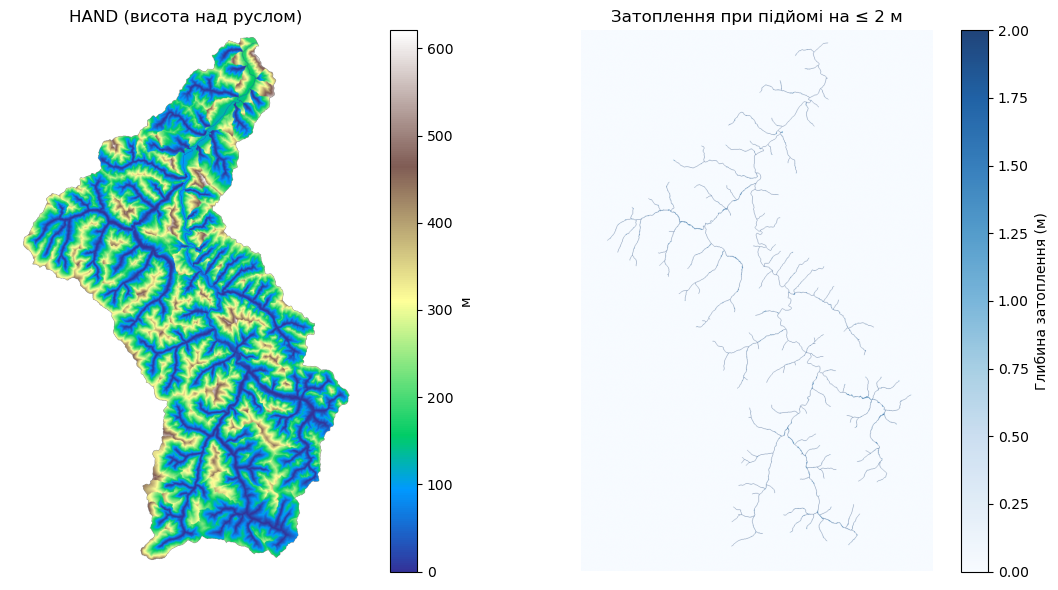

In [12]:
import rasterio
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# 🔧 Вхідний файл HAND
hand_path = Path("/mnt/c/Users/5302/OneDrive/PhD/paper_DEM_artickle/data/DATA_UTM/dem/hand_outputs/fab_dem_utm32635_hand_2000.tif")

# 📖 Читання HAND
with rasterio.open(hand_path) as src:
    hand = src.read(1)
    profile = src.profile

# 🧼 Маскуємо некоректні значення
hand = np.where((hand >= 0) & np.isfinite(hand), hand, np.nan)

# 🎯 Сценарій затоплення: ≤ 2 м
flood_mask = hand <= 2  # логічна маска
flood_depth = np.where(flood_mask, 2 - hand, 0)  # глибина затоплення

# 🎨 Візуалізація
plt.figure(figsize=(12, 6))

# HAND
plt.subplot(1, 2, 1)
plt.title("HAND (висота над руслом)")
plt.imshow(hand, cmap="terrain")
plt.colorbar(label="м")
plt.axis("off")

# Затоплення
plt.subplot(1, 2, 2)
plt.title("Затоплення при підйомі на ≤ 2 м")
plt.imshow(flood_depth, cmap="Blues", alpha=0.9)
plt.colorbar(label="Глибина затоплення (м)")
plt.axis("off")

plt.tight_layout()
plt.show()


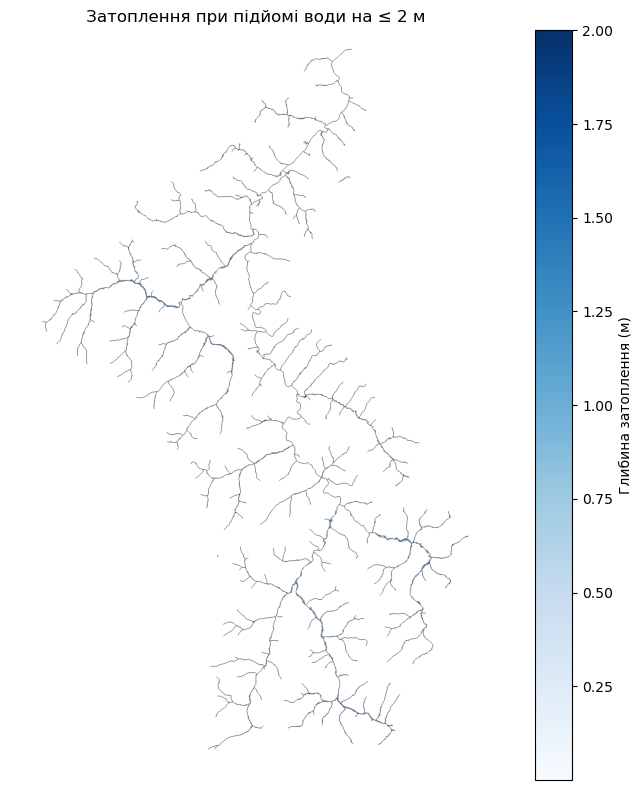

In [6]:
import rasterio
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# 🔧 Вхідний файл HAND
hand_path = Path("/mnt/c/Users/5302/OneDrive/PhD/paper_DEM_artickle/data/DATA_UTM/dem/hand_outputs/fab_dem_utm32635_hand.tif")


#  Читання HAND
with rasterio.open(hand_path) as src:
    hand = src.read(1)
    profile = src.profile

#  Маскуємо значення > 2 або недійсні
flood_depth = np.where((hand >= 0) & (hand <= 2), 2 - hand, np.nan)

#  Візуалізація
plt.figure(figsize=(8, 8))
plt.title(" Затоплення при підйомі води на ≤ 2 м")
plt.imshow(flood_depth, cmap="Blues")
plt.colorbar(label="Глибина затоплення (м)")
plt.axis("off")
plt.tight_layout()
plt.show()
